In [ ]:
# @title 1st Raw Code
# Molecular Clustering and Diversity Selection for Google Colab
# This script performs molecular clustering using ECFP4 fingerprints and Butina algorithm

# Install required packages
!pip install rdkit-pypi umap-learn seaborn plotly

# Import necessary libraries
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Draw, rdDepictor
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.manifold import TSNE
import plotly.express as px
import plotly.graph_objects as go
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("All packages installed and imported successfully!")

# Function to upload CSV file
def upload_csv():
    """Upload CSV file from local machine"""
    print("Please upload your CSV file with 'compound_name' and 'smiles' columns:")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)
    print(f"Uploaded file: {filename}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    return df

# Function to clean and validate SMILES
def clean_smiles(df):
    """Clean and validate SMILES strings using RDKit"""
    print("\nCleaning and validating SMILES...")

    # Check required columns
    if 'compound_name' not in df.columns or 'smiles' not in df.columns:
        raise ValueError("CSV must contain 'compound_name' and 'smiles' columns")

    # Remove duplicates and NaN values
    initial_count = len(df)
    df = df.dropna(subset=['smiles', 'compound_name'])
    df = df.drop_duplicates(subset=['smiles'])

    print(f"Removed {initial_count - len(df)} duplicate/invalid entries")

    # Validate SMILES and create molecule objects
    valid_mols = []
    valid_smiles = []
    valid_names = []

    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row['smiles'])
        if mol is not None:
            # Canonicalize SMILES
            canonical_smiles = Chem.MolToSmiles(mol)
            valid_mols.append(mol)
            valid_smiles.append(canonical_smiles)
            valid_names.append(row['compound_name'])

    print(f"Valid molecules: {len(valid_mols)}/{len(df)}")

    # Create clean dataframe
    clean_df = pd.DataFrame({
        'compound_name': valid_names,
        'smiles': valid_smiles,
        'mol': valid_mols
    })

    return clean_df

# Function to generate ECFP4 fingerprints
def generate_fingerprints(df, radius=2, nBits=2048):
    """Generate ECFP4 fingerprints for molecules"""
    print(f"\nGenerating ECFP{radius*2} fingerprints...")

    fingerprints = []
    for mol in df['mol']:
        fp = GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
        fingerprints.append(fp)

    df['fingerprint'] = fingerprints
    print(f"Generated {len(fingerprints)} fingerprints")
    return df

# Function to calculate Tanimoto distance matrix
def calculate_distance_matrix(fingerprints):
    """Calculate Tanimoto distance matrix"""
    print("\nCalculating Tanimoto distance matrix...")

    n = len(fingerprints)
    distance_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(i+1, n):
            tanimoto_sim = DataStructs.TanimotoSimilarity(fingerprints[i], fingerprints[j])
            tanimoto_dist = 1 - tanimoto_sim
            distance_matrix[i][j] = tanimoto_dist
            distance_matrix[j][i] = tanimoto_dist

    print(f"Distance matrix shape: {distance_matrix.shape}")
    return distance_matrix

# Function to perform Butina clustering
def butina_clustering(fingerprints, cutoff=0.6):
    """Perform Butina clustering using Tanimoto distance"""
    print(f"\nPerforming Butina clustering with cutoff: {cutoff}...")

    # Calculate distance matrix for Butina algorithm
    n = len(fingerprints)
    distances = []

    for i in range(n):
        for j in range(i+1, n):
            tanimoto_sim = DataStructs.TanimotoSimilarity(fingerprints[i], fingerprints[j])
            tanimoto_dist = 1 - tanimoto_sim
            distances.append(tanimoto_dist)

    # Perform Butina clustering
    clusters = Butina.ClusterData(distances, n, cutoff, isDistData=True)

    print(f"Number of clusters: {len(clusters)}")

    # Create cluster assignments
    cluster_assignments = [-1] * n
    for cluster_id, cluster_members in enumerate(clusters):
        for member_id in cluster_members:
            cluster_assignments[member_id] = cluster_id

    return clusters, cluster_assignments

# Function to select diverse representatives
def select_diverse_representatives(df, clusters):
    """Select one representative from each cluster (first molecule - cluster center)"""
    print("\nSelecting diverse representatives...")

    representatives = []
    cluster_info = []

    for cluster_id, cluster_members in enumerate(clusters):
        # First molecule in cluster is the centroid (Butina algorithm property)
        representative_idx = cluster_members[0]
        representatives.append(representative_idx)

        cluster_info.append({
            'cluster_id': cluster_id,
            'cluster_size': len(cluster_members),
            'representative_idx': representative_idx,
            'representative_name': df.iloc[representative_idx]['compound_name'],
            'representative_smiles': df.iloc[representative_idx]['smiles']
        })

    # Create representative dataframe
    rep_df = df.iloc[representatives].copy()
    rep_df['cluster_id'] = [info['cluster_id'] for info in cluster_info]
    rep_df['cluster_size'] = [info['cluster_size'] for info in cluster_info]

    print(f"Selected {len(representatives)} diverse representatives")
    return rep_df, cluster_info

# Function to visualize cluster sizes
def plot_cluster_sizes(cluster_info):
    """Plot cluster size distribution"""
    print("\nGenerating cluster size visualization...")

    cluster_sizes = [info['cluster_size'] for info in cluster_info]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Histogram of cluster sizes
    ax1.hist(cluster_sizes, bins=min(20, len(set(cluster_sizes))), alpha=0.7, color='skyblue', edgecolor='black')
    ax1.set_xlabel('Cluster Size')
    ax1.set_ylabel('Number of Clusters')
    ax1.set_title('Distribution of Cluster Sizes')
    ax1.grid(True, alpha=0.3)

    # Bar plot of top 20 largest clusters
    sorted_clusters = sorted(cluster_info, key=lambda x: x['cluster_size'], reverse=True)[:20]
    cluster_ids = [f"Cluster {info['cluster_id']}" for info in sorted_clusters]
    sizes = [info['cluster_size'] for info in sorted_clusters]

    ax2.bar(range(len(sizes)), sizes, color='lightcoral', alpha=0.7)
    ax2.set_xlabel('Cluster ID')
    ax2.set_ylabel('Cluster Size')
    ax2.set_title('Top 20 Largest Clusters')
    ax2.set_xticks(range(len(sizes)))
    ax2.set_xticklabels(cluster_ids, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"\nCluster Statistics:")
    print(f"Total clusters: {len(cluster_info)}")
    print(f"Average cluster size: {np.mean(cluster_sizes):.2f}")
    print(f"Median cluster size: {np.median(cluster_sizes):.2f}")
    print(f"Largest cluster size: {max(cluster_sizes)}")
    print(f"Smallest cluster size: {min(cluster_sizes)}")

# Function to create 2D chemical space visualization
def plot_chemical_space(df, cluster_assignments, method='umap'):
    """Create 2D visualization of chemical space using UMAP or t-SNE"""
    print(f"\nGenerating 2D chemical space visualization using {method.upper()}...")

    # Convert fingerprints to numpy array
    fp_array = np.array([list(fp) for fp in df['fingerprint']])

    # Perform dimensionality reduction
    if method.lower() == 'umap':
        reducer = umap.UMAP(n_components=2, random_state=42, metric='jaccard')
        embedding = reducer.fit_transform(fp_array)
    else:  # t-SNE
        reducer = TSNE(n_components=2, random_state=42, metric='jaccard', perplexity=min(30, len(df)//4))
        embedding = reducer.fit_transform(fp_array)

    # Create interactive plot with Plotly
    fig = go.Figure()

    # Get unique clusters and colors
    unique_clusters = sorted(set(cluster_assignments))
    colors = px.colors.qualitative.Set3 * (len(unique_clusters) // len(px.colors.qualitative.Set3) + 1)

    for i, cluster_id in enumerate(unique_clusters):
        cluster_mask = np.array(cluster_assignments) == cluster_id
        cluster_embedding = embedding[cluster_mask]
        cluster_names = df[cluster_mask]['compound_name'].tolist()
        cluster_smiles = df[cluster_mask]['smiles'].tolist()

        fig.add_trace(go.Scatter(
            x=cluster_embedding[:, 0],
            y=cluster_embedding[:, 1],
            mode='markers',
            name=f'Cluster {cluster_id}',
            marker=dict(color=colors[i % len(colors)], size=8, opacity=0.7),
            text=[f"Name: {name}<br>SMILES: {smiles}" for name, smiles in zip(cluster_names, cluster_smiles)],
            hovertemplate='<b>%{text}</b><br>Cluster: ' + str(cluster_id) + '<extra></extra>'
        ))

    fig.update_layout(
        title=f'2D Chemical Space Visualization ({method.upper()})',
        xaxis_title=f'{method.upper()} 1',
        yaxis_title=f'{method.upper()} 2',
        width=900,
        height=700,
        showlegend=True
    )

    fig.show()

    # Also create a matplotlib version
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(embedding[:, 0], embedding[:, 1],
                         c=cluster_assignments, cmap='tab20', alpha=0.7, s=50)
    plt.colorbar(scatter, label='Cluster ID')
    plt.xlabel(f'{method.upper()} 1')
    plt.ylabel(f'{method.upper()} 2')
    plt.title(f'2D Chemical Space Visualization ({method.upper()})')
    plt.grid(True, alpha=0.3)
    plt.show()

# Function to download results
def download_results(rep_df, cluster_info):
    """Download results as CSV files"""
    print("\nPreparing files for download...")

    # Prepare representative molecules file
    output_df = rep_df[['compound_name', 'smiles', 'cluster_id', 'cluster_size']].copy()
    output_df.to_csv('diverse_representatives.csv', index=False)

    # Prepare cluster information file
    cluster_df = pd.DataFrame(cluster_info)
    cluster_df.to_csv('cluster_information.csv', index=False)

    # Download files
    files.download('diverse_representatives.csv')
    files.download('cluster_information.csv')

    print("Files downloaded successfully!")
    print(f"- diverse_representatives.csv: {len(output_df)} compounds")
    print(f"- cluster_information.csv: {len(cluster_df)} clusters")

# Main execution function
def main():
    """Main execution pipeline"""
    print("=== Molecular Clustering and Diversity Selection ===\n")

    # Step 1: Upload CSV file
    df = upload_csv()

    # Step 2: Clean and validate SMILES
    clean_df = clean_smiles(df)

    # Step 3: Generate fingerprints
    df_with_fp = generate_fingerprints(clean_df)

    # Step 4: Perform clustering
    fingerprints = df_with_fp['fingerprint'].tolist()

    # You can adjust the cutoff value (0.4-0.8 typical range)
    cutoff = 0.6  # Lower values = more clusters (more diversity)
    clusters, cluster_assignments = butina_clustering(fingerprints, cutoff=cutoff)

    # Add cluster assignments to dataframe
    df_with_fp['cluster_id'] = cluster_assignments

    # Step 5: Select diverse representatives
    rep_df, cluster_info = select_diverse_representatives(df_with_fp, clusters)

    # Step 6: Visualizations
    plot_cluster_sizes(cluster_info)
    plot_chemical_space(df_with_fp, cluster_assignments, method='umap')

    # Step 7: Download results
    download_results(rep_df, cluster_info)

    return df_with_fp, rep_df, cluster_info

# Run the complete pipeline
if __name__ == "__main__":
    # Execute main pipeline
    full_df, representatives_df, cluster_information = main()

    print("\n=== Pipeline Complete! ===")
    print(f"Original compounds: {len(full_df)}")
    print(f"Diverse representatives selected: {len(representatives_df)}")
    print(f"Reduction ratio: {len(representatives_df)/len(full_df):.2%}")

# Optional: Additional utility functions

def adjust_clustering_cutoff(df_with_fp, new_cutoff=0.5):
    """Re-run clustering with different cutoff value"""
    print(f"\nRe-clustering with cutoff = {new_cutoff}")
    fingerprints = df_with_fp['fingerprint'].tolist()
    clusters, cluster_assignments = butina_clustering(fingerprints, cutoff=new_cutoff)

    df_with_fp['cluster_id'] = cluster_assignments
    rep_df, cluster_info = select_diverse_representatives(df_with_fp, clusters)

    plot_cluster_sizes(cluster_info)
    return rep_df, cluster_info

def show_cluster_examples(df_with_fp, cluster_id, max_examples=5):
    """Show example molecules from a specific cluster"""
    cluster_mols = df_with_fp[df_with_fp['cluster_id'] == cluster_id]

    print(f"\nCluster {cluster_id} examples ({len(cluster_mols)} total molecules):")
    for i, (_, row) in enumerate(cluster_mols.head(max_examples).iterrows()):
        print(f"{i+1}. {row['compound_name']}: {row['smiles']}")

    # Draw molecules if possible
    try:
        mols = [row['mol'] for _, row in cluster_mols.head(max_examples).iterrows()]
        legends = [row['compound_name'] for _, row in cluster_mols.head(max_examples).iterrows()]
        img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=legends)
        display(img)
    except:
        print("Could not display molecular structures")

print("\n=== Ready to use! ===")
print("Run main() to start the complete pipeline")
print("Or use individual functions for custom analysis")
print("\nExample usage:")
print("# Run complete pipeline")
print("full_df, representatives_df, cluster_information = main()")
print("\n# Adjust clustering cutoff")
print("new_reps, new_clusters = adjust_clustering_cutoff(full_df, new_cutoff=0.4)")
print("\n# Show examples from cluster 0")
print("show_cluster_examples(full_df, cluster_id=0)")

In [ ]:
# @title Raw Code
# prompt: Download all result csv file and all visualization plot

# Add imports for saving plotly figures
!pip install kaleido

# Modify the download_results function to also save plots
def download_results(rep_df, cluster_info, full_df=None, cluster_assignments=None):
    """Download results as CSV files and save/download plots"""
    print("\nPreparing files for download...")

    # Prepare representative molecules file
    output_df = rep_df[['compound_name', 'smiles', 'cluster_id', 'cluster_size']].copy()
    representatives_filename = 'diverse_representatives.csv'
    output_df.to_csv(representatives_filename, index=False)

    # Prepare cluster information file
    cluster_df = pd.DataFrame(cluster_info)
    cluster_info_filename = 'cluster_information.csv'
    cluster_df.to_csv(cluster_info_filename, index=False)

    print(f"CSV files saved: {representatives_filename}, {cluster_info_filename}")

    # Save and download Matplotlib plots
    print("\nSaving and downloading Matplotlib plots...")
    # Assuming plot_cluster_sizes generates a Matplotlib plot
    try:
        plot_cluster_sizes(cluster_info) # This function generates the plot
        cluster_size_plot_filename = 'cluster_size_distribution.png'
        plt.savefig(cluster_size_plot_filename, bbox_inches='tight')
        print(f"Saved Matplotlib plot: {cluster_size_plot_filename}")
        files.download(cluster_size_plot_filename)
    except Exception as e:
        print(f"Could not save/download cluster size plot: {e}")
    finally:
        plt.close() # Close the matplotlib figure

    # Save and download Plotly figures
    print("\nSaving and downloading Plotly plots...")
    if full_df is not None and cluster_assignments is not None:
        try:
            # This function generates the Plotly figure (and shows it)
            fig = plot_chemical_space(full_df, cluster_assignments, method='umap') # Need to modify plot_chemical_space to return the fig

            if fig:
                chemical_space_plot_filename = 'chemical_space_umap.html' # HTML for interactive Plotly
                fig.write_html(chemical_space_plot_filename)
                print(f"Saved Plotly plot (HTML): {chemical_space_plot_filename}")
                files.download(chemical_space_plot_filename)

                # Optional: Save as static image (requires kaleido)
                try:
                    chemical_space_plot_png_filename = 'chemical_space_umap.png'
                    fig.write_image(chemical_space_plot_png_filename)
                    print(f"Saved Plotly plot (PNG): {chemical_space_plot_png_filename}")
                    files.download(chemical_space_plot_png_filename)
                except Exception as e:
                    print(f"Could not save static Plotly image (PNG): {e}")

        except Exception as e:
            print(f"Could not save/download chemical space plot: {e}")

    # Download CSV files
    print("\nDownloading CSV files...")
    files.download(representatives_filename)
    files.download(cluster_info_filename)

    print("\nAll requested files attempted for download.")


# Modify plot_chemical_space to return the plotly figure object
def plot_chemical_space(df, cluster_assignments, method='umap'):
    """Create 2D visualization of chemical space using UMAP or t-SNE and return Plotly figure"""
    print(f"\nGenerating 2D chemical space visualization using {method.upper()}...")

    # Convert fingerprints to numpy array
    fp_array = np.array([list(fp) for fp in df['fingerprint']])

    # Perform dimensionality reduction
    if method.lower() == 'umap':
        reducer = umap.UMAP(n_components=2, random_state=42, metric='jaccard')
        embedding = reducer.fit_transform(fp_array)
    else:  # t-SNE
        reducer = TSNE(n_components=2, random_state=42, metric='jaccard', perplexity=min(30, len(df)//4))
        embedding = reducer.fit_transform(fp_array)

    # Create interactive plot with Plotly
    fig = go.Figure()

    # Get unique clusters and colors
    unique_clusters = sorted(set(cluster_assignments))
    colors = px.colors.qualitative.Set3 * (len(unique_clusters) // len(px.colors.qualitative.Set3) + 1)

    for i, cluster_id in enumerate(unique_clusters):
        cluster_mask = np.array(cluster_assignments) == cluster_id
        cluster_embedding = embedding[cluster_mask]
        cluster_names = df[cluster_mask]['compound_name'].tolist()
        cluster_smiles = df[cluster_mask]['smiles'].tolist()

        fig.add_trace(go.Scatter(
            x=cluster_embedding[:, 0],
            y=cluster_embedding[:, 1],
            mode='markers',
            name=f'Cluster {cluster_id}',
            marker=dict(color=colors[i % len(colors)], size=8, opacity=0.7),
            text=[f"Name: {name}<br>SMILES: {smiles}" for name, smiles in zip(cluster_names, cluster_smiles)],
            hovertemplate='<b>%{text}</b><br>Cluster: ' + str(cluster_id) + '<extra></extra>'
        ))

    fig.update_layout(
        title=f'2D Chemical Space Visualization ({method.upper()})',
        xaxis_title=f'{method.upper()} 1',
        yaxis_title=f'{method.upper()} 2',
        width=900,
        height=700,
        showlegend=True
    )

    # Show the figure in the notebook output
    fig.show()

    # Also create and show a matplotlib version
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(embedding[:, 0], embedding[:, 1],
                         c=cluster_assignments, cmap='tab20', alpha=0.7, s=50)
    plt.colorbar(scatter, label='Cluster ID')
    plt.xlabel(f'{method.upper()} 1')
    plt.ylabel(f'{method.upper()} 2')
    plt.title(f'2D Chemical Space Visualization ({method.upper()})')
    plt.grid(True, alpha=0.3)
    plt.show()

    return fig # Return the plotly figure object


# Modify the main function to pass required data to download_results
def main():
    """Main execution pipeline"""
    print("=== Molecular Clustering and Diversity Selection ===\n")

    # Step 1: Upload CSV file
    df = upload_csv()

    # Step 2: Clean and validate SMILES
    clean_df = clean_smiles(df)

    # Step 3: Generate fingerprints
    df_with_fp = generate_fingerprints(clean_df)

    # Step 4: Perform clustering
    fingerprints = df_with_fp['fingerprint'].tolist()

    # You can adjust the cutoff value (0.4-0.8 typical range)
    cutoff = 0.6  # Lower values = more clusters (more diversity)
    clusters, cluster_assignments = butina_clustering(fingerprints, cutoff=cutoff)

    # Add cluster assignments to dataframe
    df_with_fp['cluster_id'] = cluster_assignments

    # Step 5: Select diverse representatives
    rep_df, cluster_info = select_diverse_representatives(df_with_fp, clusters)

    # Step 6: Visualizations (now handled within download_results or called before)
    # plot_cluster_sizes(cluster_info) # Called inside download_results
    # plot_chemical_space(df_with_fp, cluster_assignments, method='umap') # Called inside download_results

    # Step 7: Download results (and now saves plots)
    download_results(rep_df, cluster_info, full_df=df_with_fp, cluster_assignments=cluster_assignments)

    return df_with_fp, rep_df, cluster_info

# Run the complete pipeline
# The __main__ block remains the same and calls main()
if __name__ == "__main__":
    # Execute main pipeline
    full_df, representatives_df, cluster_information = main()

    print("\n=== Pipeline Complete! ===")
    print(f"Original compounds: {len(full_df)}")
    print(f"Diverse representatives selected: {len(representatives_df)}")
    print(f"Reduction ratio: {len(representatives_df)/len(full_df):.2%}")



Installing required packages...
All libraries imported successfully!
=== MOLECULAR CLUSTERING AND DIVERSITY SELECTION ===

Please upload your CSV file containing 'compound_name' and 'smiles' columns...


Saving final_filtered_compounds.csv to final_filtered_compounds.csv
File 'final_filtered_compounds.csv' uploaded successfully!
Dataset loaded: 3879 compounds
After cleaning: 3879 compounds (removed 0 duplicates/empty entries)
Parsing SMILES and generating ECFP4 fingerprints...
Successfully generated fingerprints for 3879 compounds
Performing Butina clustering with distance threshold: 0.8
Clustering completed: 95 clusters found
Selecting up to 3 representatives per cluster...
Selected 228 diverse representatives from 95 clusters
Creating visualizations...


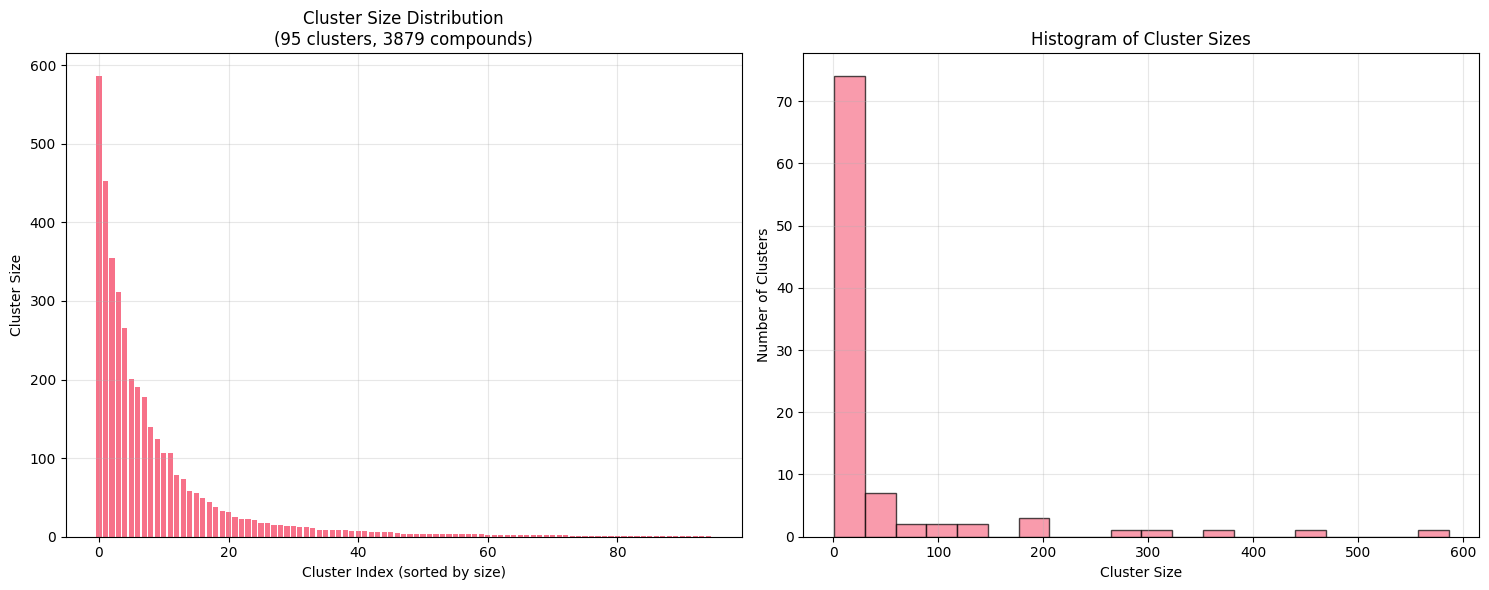

Generating UMAP embedding...


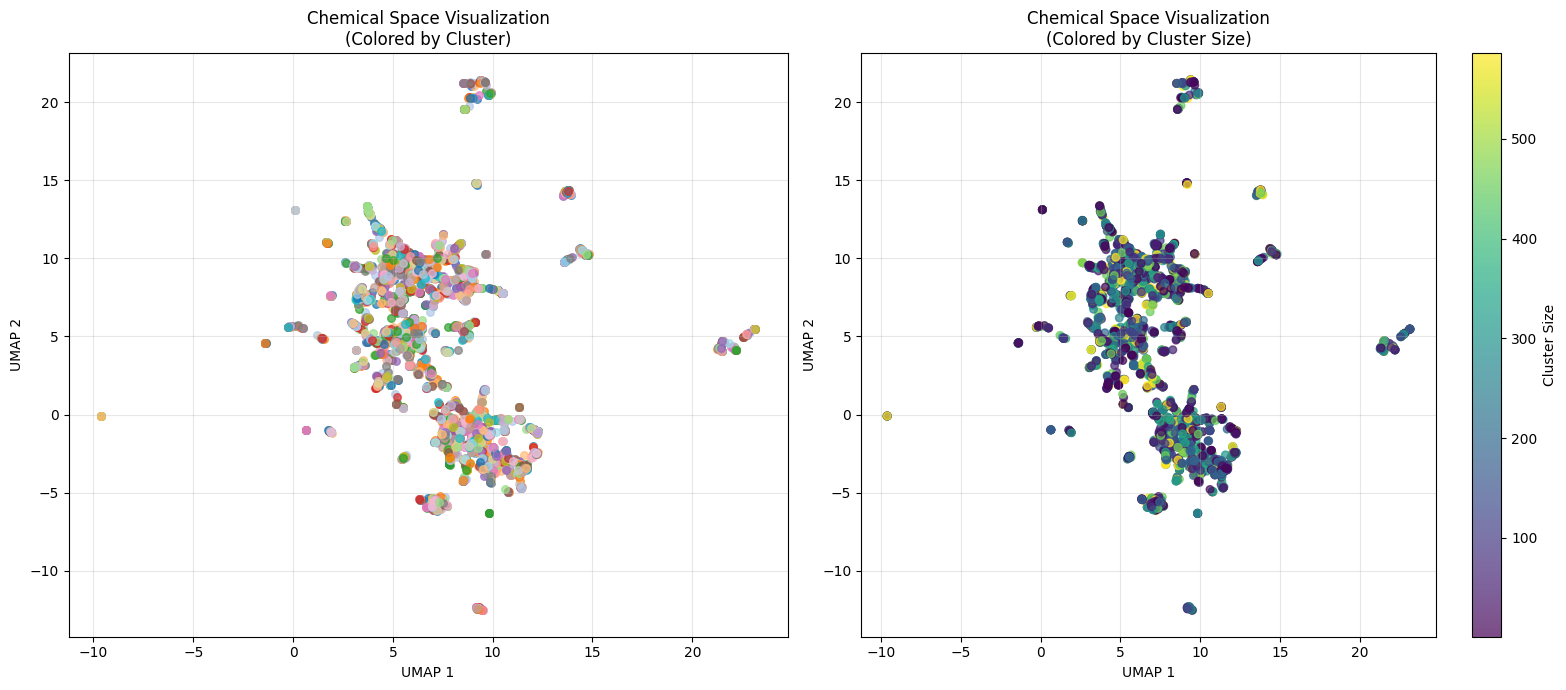

Generating summary report...
Summary report generated!

MOLECULAR CLUSTERING AND DIVERSITY SELECTION REPORT
Generated on: 2025-06-29 16:29:18

DATASET SUMMARY:
- Total compounds processed: 3879
- Total clusters identified: 95
- Total diverse representatives selected: 228
- Distance threshold used: 0.8

CLUSTERING STATISTICS:
- Largest cluster size: 586
- Smallest cluster size: 1
- Average cluster size: 40.83
- Median cluster size: 4.00
- Standard deviation: 96.17

CLUSTER SIZE DISTRIBUTION:
- Singleton clusters (size 1): 22
- Small clusters (size 2-5): 27
- Medium clusters (size 6-20): 21
- Large clusters (size >20): 25

DIVERSITY SELECTION SUMMARY:
- Total representatives: 228
- Diversity coverage: 5.9% of original dataset
- Average representatives per cluster: 2.40

METHODOLOGY:
1. SMILES strings were parsed using RDKit
2. ECFP4 fingerprints (radius=2, 2048 bits) were generated
3. Tanimoto distance was calculated between all compound pairs
4. Butina clustering algorithm was applied
5

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== ANALYSIS COMPLETE ===
Successfully processed 3879 compounds
Found 95 clusters
Selected 228 diverse representatives
All results have been packaged and downloaded!


In [ ]:
# @title Final Code
# Molecular Clustering and Diversity Selection
# Complete Google Colab Implementation

# Step 1: Install required packages
print("Installing required packages...")
!pip install rdkit-pypi umap-learn seaborn zipfile36 --quiet

# Step 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, DataStructs
from rdkit.ML.Cluster import Butina
from google.colab import files
import umap
import zipfile
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

# Step 3: Upload CSV file
def upload_csv():
    """Upload CSV file containing compound_name and smiles columns"""
    print("Please upload your CSV file containing 'compound_name' and 'smiles' columns...")
    uploaded = files.upload()

    if not uploaded:
        raise ValueError("No file uploaded!")

    filename = list(uploaded.keys())[0]
    print(f"File '{filename}' uploaded successfully!")
    return filename

# Step 4: Load and validate data
def load_and_validate_data(filename):
    """Load CSV and validate required columns"""
    try:
        df = pd.read_csv(filename)
        print(f"Dataset loaded: {len(df)} compounds")

        # Check required columns
        required_cols = ['compound_name', 'smiles']
        missing_cols = [col for col in required_cols if col not in df.columns]

        if missing_cols:
            print(f"Available columns: {list(df.columns)}")
            raise ValueError(f"Missing required columns: {missing_cols}")

        # Remove duplicates and empty SMILES
        initial_count = len(df)
        df = df.dropna(subset=['smiles', 'compound_name'])
        df = df.drop_duplicates(subset=['smiles'])
        df = df.reset_index(drop=True)

        print(f"After cleaning: {len(df)} compounds (removed {initial_count - len(df)} duplicates/empty entries)")
        return df

    except Exception as e:
        print(f"Error loading data: {e}")
        raise

# Step 5: Parse SMILES and generate fingerprints
def generate_fingerprints(df):
    """Parse SMILES and generate ECFP4 fingerprints"""
    print("Parsing SMILES and generating ECFP4 fingerprints...")

    molecules = []
    fingerprints = []
    valid_indices = []

    for idx, smiles in enumerate(df['smiles']):
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                # Generate ECFP4 fingerprint (radius=2, 2048 bits)
                fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
                molecules.append(mol)
                fingerprints.append(fp)
                valid_indices.append(idx)
            else:
                print(f"Invalid SMILES at index {idx}: {smiles}")
        except Exception as e:
            print(f"Error processing SMILES at index {idx}: {e}")

    # Filter dataframe to keep only valid molecules
    df_valid = df.iloc[valid_indices].reset_index(drop=True)

    print(f"Successfully generated fingerprints for {len(fingerprints)} compounds")
    return df_valid, molecules, fingerprints

# Step 6: Calculate Tanimoto distance matrix
def calculate_distance_matrix(fingerprints):
    """Calculate Tanimoto distance matrix"""
    print("Calculating Tanimoto distance matrix...")

    n_compounds = len(fingerprints)
    distance_matrix = np.zeros((n_compounds, n_compounds))

    for i in range(n_compounds):
        for j in range(i+1, n_compounds):
            # Calculate Tanimoto similarity
            similarity = DataStructs.TanimotoSimilarity(fingerprints[i], fingerprints[j])
            # Convert to distance (1 - similarity)
            distance = 1 - similarity
            distance_matrix[i][j] = distance
            distance_matrix[j][i] = distance

    print("Distance matrix calculated!")
    return distance_matrix

# Step 7: Perform Butina clustering
def perform_clustering(fingerprints, distance_threshold=0.4):
    """Perform Butina clustering"""
    print(f"Performing Butina clustering with distance threshold: {distance_threshold}")

    # Calculate distance matrix for Butina clustering
    n_compounds = len(fingerprints)
    distances = []

    for i in range(n_compounds):
        for j in range(i+1, n_compounds):
            similarity = DataStructs.TanimotoSimilarity(fingerprints[i], fingerprints[j])
            distance = 1 - similarity
            distances.append(distance)

    # Perform Butina clustering
    clusters = Butina.ClusterData(distances, n_compounds, distance_threshold, isDistData=True)

    print(f"Clustering completed: {len(clusters)} clusters found")

    # Create cluster assignments
    cluster_assignments = np.zeros(n_compounds, dtype=int)
    for cluster_id, cluster_members in enumerate(clusters):
        for member_idx in cluster_members:
            cluster_assignments[member_idx] = cluster_id

    return clusters, cluster_assignments

# Step 8: Select diverse representatives
def select_diverse_representatives(df, fingerprints, clusters, max_per_cluster=3):
    """Select diverse representatives from each cluster"""
    print(f"Selecting up to {max_per_cluster} representatives per cluster...")

    representatives = []

    for cluster_id, cluster_members in enumerate(clusters):
        cluster_size = len(cluster_members)

        if cluster_size == 1:
            # Single compound cluster
            representatives.append({
                'cluster_id': cluster_id,
                'compound_idx': cluster_members[0],
                'compound_name': df.iloc[cluster_members[0]]['compound_name'],
                'smiles': df.iloc[cluster_members[0]]['smiles'],
                'cluster_size': cluster_size,
                'selection_method': 'singleton'
            })
        else:
            # Multiple compounds - select diverse representatives
            if cluster_size <= max_per_cluster:
                # Select all if cluster is small
                selected_indices = cluster_members
                method = 'all_selected'
            else:
                # Select diverse representatives
                # Calculate intra-cluster distances
                cluster_fps = [fingerprints[i] for i in cluster_members]
                intra_distances = np.zeros((len(cluster_members), len(cluster_members)))

                for i in range(len(cluster_members)):
                    for j in range(i+1, len(cluster_members)):
                        sim = DataStructs.TanimotoSimilarity(cluster_fps[i], cluster_fps[j])
                        dist = 1 - sim
                        intra_distances[i][j] = dist
                        intra_distances[j][i] = dist

                # Select most diverse compounds using farthest-first traversal
                selected_local_indices = [0]  # Start with first compound

                for _ in range(min(max_per_cluster - 1, len(cluster_members) - 1)):
                    max_min_distance = -1
                    best_candidate = -1

                    for candidate in range(len(cluster_members)):
                        if candidate in selected_local_indices:
                            continue

                        # Find minimum distance to already selected compounds
                        min_distance = min(intra_distances[candidate][selected]
                                         for selected in selected_local_indices)

                        if min_distance > max_min_distance:
                            max_min_distance = min_distance
                            best_candidate = candidate

                    if best_candidate != -1:
                        selected_local_indices.append(best_candidate)

                selected_indices = [cluster_members[i] for i in selected_local_indices]
                method = 'diverse_selection'

            # Add selected representatives
            for idx in selected_indices:
                representatives.append({
                    'cluster_id': cluster_id,
                    'compound_idx': idx,
                    'compound_name': df.iloc[idx]['compound_name'],
                    'smiles': df.iloc[idx]['smiles'],
                    'cluster_size': cluster_size,
                    'selection_method': method
                })

    representatives_df = pd.DataFrame(representatives)
    print(f"Selected {len(representatives_df)} diverse representatives from {len(clusters)} clusters")

    return representatives_df

# Step 9: Create visualizations
def create_visualizations(df, fingerprints, cluster_assignments, clusters):
    """Create visualizations for clustering results"""
    print("Creating visualizations...")

    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")

    # Figure 1: Cluster size distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Cluster sizes bar plot
    cluster_sizes = [len(cluster) for cluster in clusters]
    ax1.bar(range(len(cluster_sizes)), sorted(cluster_sizes, reverse=True))
    ax1.set_xlabel('Cluster Index (sorted by size)')
    ax1.set_ylabel('Cluster Size')
    ax1.set_title(f'Cluster Size Distribution\n({len(clusters)} clusters, {len(df)} compounds)')
    ax1.grid(True, alpha=0.3)

    # Cluster size histogram
    ax2.hist(cluster_sizes, bins=min(20, len(cluster_sizes)), edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Cluster Size')
    ax2.set_ylabel('Number of Clusters')
    ax2.set_title('Histogram of Cluster Sizes')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('cluster_size_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Figure 2: UMAP visualization of chemical space
    print("Generating UMAP embedding...")

    # Convert fingerprints to numpy array
    fp_array = np.array([list(fp) for fp in fingerprints])

    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP(n_neighbors=15, n_components=2, metric='jaccard', random_state=42)
    embedding = reducer.fit_transform(fp_array)

    # Create UMAP plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Plot 1: Colored by cluster
    n_clusters = len(clusters)
    colors = plt.cm.tab20(np.linspace(0, 1, min(n_clusters, 20)))

    for i in range(n_clusters):
        cluster_mask = cluster_assignments == i
        if np.sum(cluster_mask) > 0:
            color = colors[i % len(colors)]
            ax1.scatter(embedding[cluster_mask, 0], embedding[cluster_mask, 1],
                       c=[color], label=f'Cluster {i}', alpha=0.7, s=30)

    ax1.set_xlabel('UMAP 1')
    ax1.set_ylabel('UMAP 2')
    ax1.set_title('Chemical Space Visualization\n(Colored by Cluster)')
    ax1.grid(True, alpha=0.3)

    # Only show legend if we have few clusters
    if n_clusters <= 10:
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Plot 2: Colored by cluster size
    cluster_size_map = {i: len(clusters[i]) for i in range(len(clusters))}
    point_sizes = [cluster_size_map[cluster_assignments[i]] for i in range(len(df))]

    scatter = ax2.scatter(embedding[:, 0], embedding[:, 1],
                         c=point_sizes, cmap='viridis', alpha=0.7, s=30)
    ax2.set_xlabel('UMAP 1')
    ax2.set_ylabel('UMAP 2')
    ax2.set_title('Chemical Space Visualization\n(Colored by Cluster Size)')
    ax2.grid(True, alpha=0.3)

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Cluster Size')

    plt.tight_layout()
    plt.savefig('chemical_space_umap.png', dpi=300, bbox_inches='tight')
    plt.show()

    return embedding

# Step 10: Generate summary report
def generate_summary_report(df, clusters, representatives_df, distance_threshold):
    """Generate a comprehensive summary report"""
    print("Generating summary report...")

    # Calculate statistics
    cluster_sizes = [len(cluster) for cluster in clusters]
    total_compounds = len(df)
    total_clusters = len(clusters)
    total_representatives = len(representatives_df)

    # Create summary text
    summary = f"""
MOLECULAR CLUSTERING AND DIVERSITY SELECTION REPORT
================================================
Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

DATASET SUMMARY:
- Total compounds processed: {total_compounds}
- Total clusters identified: {total_clusters}
- Total diverse representatives selected: {total_representatives}
- Distance threshold used: {distance_threshold}

CLUSTERING STATISTICS:
- Largest cluster size: {max(cluster_sizes)}
- Smallest cluster size: {min(cluster_sizes)}
- Average cluster size: {np.mean(cluster_sizes):.2f}
- Median cluster size: {np.median(cluster_sizes):.2f}
- Standard deviation: {np.std(cluster_sizes):.2f}

CLUSTER SIZE DISTRIBUTION:
- Singleton clusters (size 1): {sum(1 for size in cluster_sizes if size == 1)}
- Small clusters (size 2-5): {sum(1 for size in cluster_sizes if 2 <= size <= 5)}
- Medium clusters (size 6-20): {sum(1 for size in cluster_sizes if 6 <= size <= 20)}
- Large clusters (size >20): {sum(1 for size in cluster_sizes if size > 20)}

DIVERSITY SELECTION SUMMARY:
- Total representatives: {total_representatives}
- Diversity coverage: {(total_representatives/total_compounds)*100:.1f}% of original dataset
- Average representatives per cluster: {total_representatives/total_clusters:.2f}

METHODOLOGY:
1. SMILES strings were parsed using RDKit
2. ECFP4 fingerprints (radius=2, 2048 bits) were generated
3. Tanimoto distance was calculated between all compound pairs
4. Butina clustering algorithm was applied
5. Diverse representatives were selected using farthest-first traversal
6. Chemical space was visualized using UMAP dimensionality reduction

FILES GENERATED:
- clustering_results.csv: Full clustering results with assignments
- diverse_representatives.csv: Selected diverse representatives
- cluster_size_analysis.png: Cluster size distribution plots
- chemical_space_umap.png: UMAP visualization of chemical space
- summary_report.txt: This summary report

INTERPRETATION NOTES:
- Smaller distance thresholds create more clusters (higher resolution)
- Larger distance thresholds create fewer clusters (lower resolution)
- UMAP visualization shows the 2D projection of high-dimensional chemical space
- Diverse representatives maintain chemical diversity while reducing dataset size
"""

    # Save summary to file
    with open('summary_report.txt', 'w') as f:
        f.write(summary)

    print("Summary report generated!")
    return summary

# Step 11: Create downloadable ZIP package
def create_zip_package(df, representatives_df, cluster_assignments):
    """Package all results into a ZIP file"""
    print("Creating downloadable ZIP package...")

    # Add cluster assignments to original dataframe
    df_with_clusters = df.copy()
    df_with_clusters['cluster_id'] = cluster_assignments
    df_with_clusters['cluster_size'] = df_with_clusters['cluster_id'].map(
        df_with_clusters['cluster_id'].value_counts()
    )

    # Save CSV files
    df_with_clusters.to_csv('clustering_results.csv', index=False)
    representatives_df.to_csv('diverse_representatives.csv', index=False)

    # Create ZIP file
    zip_filename = f'molecular_clustering_results_{datetime.now().strftime("%Y%m%d_%H%M%S")}.zip'

    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        # Add CSV files
        zipf.write('clustering_results.csv')
        zipf.write('diverse_representatives.csv')

        # Add visualization files
        if os.path.exists('cluster_size_analysis.png'):
            zipf.write('cluster_size_analysis.png')
        if os.path.exists('chemical_space_umap.png'):
            zipf.write('chemical_space_umap.png')

        # Add summary report
        if os.path.exists('summary_report.txt'):
            zipf.write('summary_report.txt')

    print(f"ZIP package created: {zip_filename}")
    return zip_filename

# Step 12: Main execution function
def main():
    """Main execution function"""
    try:
        print("=== MOLECULAR CLUSTERING AND DIVERSITY SELECTION ===\n")

        # Step 1: Upload and load data
        filename = upload_csv()
        df = load_and_validate_data(filename)

        # Step 2: Generate fingerprints
        df_valid, molecules, fingerprints = generate_fingerprints(df)

        if len(fingerprints) == 0:
            raise ValueError("No valid molecules found!")

        # Step 3: Perform clustering
        distance_threshold = 0.8  # Adjust as needed
        clusters, cluster_assignments = perform_clustering(fingerprints, distance_threshold)

        # Step 4: Select diverse representatives
        representatives_df = select_diverse_representatives(
            df_valid, fingerprints, clusters, max_per_cluster=3
        )

        # Step 5: Create visualizations
        embedding = create_visualizations(df_valid, fingerprints, cluster_assignments, clusters)

        # Step 6: Generate summary report
        summary = generate_summary_report(df_valid, clusters, representatives_df, distance_threshold)
        print(summary)

        # Step 7: Create ZIP package
        zip_filename = create_zip_package(df_valid, representatives_df, cluster_assignments)

        # Step 8: Download results
        print("\n=== RESULTS READY FOR DOWNLOAD ===")
        files.download(zip_filename)

        print("\n=== ANALYSIS COMPLETE ===")
        print(f"Successfully processed {len(df_valid)} compounds")
        print(f"Found {len(clusters)} clusters")
        print(f"Selected {len(representatives_df)} diverse representatives")
        print("All results have been packaged and downloaded!")

        return df_valid, representatives_df, clusters, embedding

    except Exception as e:
        print(f"Error in main execution: {e}")
        raise

# Step 13: Execute the analysis
if __name__ == "__main__":
    # Run the complete analysis
    results = main()